In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time # For Duration it takes for each model to train
import datetime # For transforming datetime values

# Scikit-Learn Models
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# Scikit-Learn Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Scikit-Learn Model Selection
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Scikit-Learn Metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error, \
mean_absolute_percentage_error, mean_absolute_error

# XGB/LGBM Models
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Optuna HyperParameter Tuning
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

C:\Users\kenne\miniconda3\envs\ml_py3.12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv(r"C:\Users\kenne\Downloads\MEG_DATASET\CLEANED_DATASETS_JAN to FEB_2026.csv")
dataset = df.copy()

# 1. DATA PROFILING

In [4]:
print("Data Types:\n", dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3229 entries, 0 to 3228
Data columns (total 11 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   PAYEE                                         3229 non-null   object 
 1   PROJECT                                       3229 non-null   object 
 2   CHECK NO                                      3229 non-null   object 
 3   AMOUNT                                        3229 non-null   float64
 4   APV NO                                        3229 non-null   object 
 5   CV NO                                         3229 non-null   object 
 6   PO NO                                         3224 non-null   object 
 7   COMPANY                                       3229 non-null   object 
 8   DATE OF INCLUSION IN THE LIST OF FOR RELEASE  3229 non-null   object 
 9   RELEASING VENUE                               3229 non-null   o

# 2. FEATURE ENGINEERING

In [ ]:
'''
As we notice, there are 5 items missing for PO NO column.

There are 1,193 missing items in BILLING NO. column.

For columns: 

CHECK NO - CHECK NO column only has 2 values.
APV NO - We'll replace values that has "MBPHI-APVTRD to "THRU_PRISM"
CV NO - Since CV NO column is same with "CHECK NO", we'll drop this.
PO NO - We will drop this column since it is only unique identifier.
BILLING NO. - We'll drop this also since imputing it randomly generates random noise

'''

In [5]:
df["CHECK NO"].value_counts()

CHECK NO
CHECKWRITER      274
9900000000000    244
9900000033475      5
9900000033578      5
9900000033477      5
                ... 
9900000033919      1
9900000033920      1
7461549            1
7461544            1
9900000022195      1
Name: count, Length: 2056, dtype: int64

# 3. DATA CLEANING

In [3]:
def data_cleaning(dataframe):
    
    # Correcting Releasing Venue
    dataframe["RELEASING VENUE"] = dataframe["RELEASING VENUE"].replace(
    "ALLIANCE GLOBAL TOWER – BASEMENT 6 (1-4pm)",
    "ALLIANCE GLOBAL TOWER – BASEMENT 6 (1-3pm)")

    dataframe["RELEASING VENUE"] = dataframe["RELEASING VENUE"].replace(
    "BDO - ILOILO",
    "BDO ILOILO")
    
    # Replace everything except "CHECKWRITTER" with "CHECKNO"
    dataframe["CHECK NO"] = dataframe["CHECK NO"].apply(lambda x: x if x == "CHECKWRITTER" else "CHECKNO")

    # Replace APV No with Thru PRISM and make it boolean
    dataframe["THRU_PRISM"] = dataframe["APV NO"].str.contains("MBPHI-HO-APVTRD", na=False)

    dataframe["amount_bin"] = pd.cut(dataframe["AMOUNT"],
                                 bins=[0, 100000, 500000, 1000000, 10000000],
                                 labels=["<100k", "100k-500k", "500k-1M", ">1M"])

    # For DateTime Format
    dataframe["day"] = pd.to_datetime(dataframe["DATE OF INCLUSION IN THE LIST OF FOR RELEASE"]).dt.day
    dataframe["month"] = pd.to_datetime(dataframe["DATE OF INCLUSION IN THE LIST OF FOR RELEASE"]).dt.month
    dataframe["year"] = pd.to_datetime(dataframe["DATE OF INCLUSION IN THE LIST OF FOR RELEASE"]).dt.year
    dataframe["weekday"] = pd.to_datetime(dataframe["DATE OF INCLUSION IN THE LIST OF FOR RELEASE"]).dt.day_name()
    
    # The usual check release is Friday
    dataframe["is_Friday"] = pd.to_datetime(dataframe["DATE OF INCLUSION IN THE LIST OF FOR RELEASE"]).dt.day_name() == "Friday"
    dataframe["is_AGT"] = (dataframe["RELEASING VENUE"] == "ALLIANCE GLOBAL TOWER – BASEMENT 6 (1-3pm)").astype(bool)

    # Dropping Irrelevant Columns
    dataframe.drop(columns=["APV NO", "CV NO", "PO NO", "BILLING NO.","DATE OF INCLUSION IN THE LIST OF FOR RELEASE"], inplace=True)
    
    return dataframe
    
data_cleaned = data_cleaning(dataset)

In [36]:
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3229 entries, 0 to 3228
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   PAYEE            3229 non-null   object  
 1   PROJECT          3229 non-null   object  
 2   CHECK NO         3229 non-null   object  
 3   AMOUNT           3229 non-null   float64 
 4   COMPANY          3229 non-null   object  
 5   RELEASING VENUE  3229 non-null   object  
 6   THRU_PRISM       3229 non-null   bool    
 7   amount_bin       3177 non-null   category
 8   day              3229 non-null   int32   
 9   month            3229 non-null   int32   
 10  year             3229 non-null   int32   
 11  weekday          3229 non-null   object  
 12  is_Friday        3229 non-null   bool    
 13  is_AGT           3229 non-null   bool    
dtypes: bool(3), category(1), float64(1), int32(3), object(6)
memory usage: 227.4+ KB


In [14]:
data_cleaned.head(3)

,PAYEE,PROJECT,CHECK NO,AMOUNT,COMPANY,RELEASING VENUE,THRU_PRISM,amount_bin,day,month,year,weekday,is_Friday,is_AGT
0,A M ORETA & CO INC,SUNNY COAST RESIDENTAIL RESORT,CHECKNO,294348.21,"MANILA BAYSHORE PROPERTY HOLDINGS, INC.",ALLIANCE GLOBAL TOWER – BASEMENT 6 (1-3pm),True,100k-500k,23,1,2026,Friday,True,True
1,A M ORETA & CO INC,SUNNY COAST RESIDENTAIL RESORT,CHECKNO,139218.75,"MANILA BAYSHORE PROPERTY HOLDINGS, INC.",ALLIANCE GLOBAL TOWER – BASEMENT 6 (1-3pm),True,100k-500k,23,1,2026,Friday,True,True
2,A M ORETA & CO INC,SUNNY COAST RESIDENTAIL RESORT,CHECKNO,986464.29,"MANILA BAYSHORE PROPERTY HOLDINGS, INC.",ALLIANCE GLOBAL TOWER – BASEMENT 6 (1-3pm),True,500k-1M,23,1,2026,Friday,True,True


# 4. DATA PRE-PROCESSING

In [5]:
def linear_regression_model(df, target):
    """
    Train scikit-learn models with Optuna hyperparameter tuning.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataframe containing features and target variable
    target : str
        Name of the target column
        
    Returns:
    --------
    dict : Dictionary containing best models, parameters, and performance metrics
    """
    
    start_time = time.time()
    
    # Split the data into features and target variable
    X = df.drop(columns=[target])
    y = df[target]
    
    # Convert categorical variables to numerical using one-hot encoding
    X = pd.get_dummies(X, drop_first=True)
    
    # Split the dataset into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    # Model configurations with hyperparameter search spaces
    models_config = {
        'Linear Regression': {
            'model': LinearRegression(),
            'params': lambda trial: {
                'fit_intercept': trial.suggest_categorical('fit_intercept', [True, False])
            },
            'n_trials': 5
        },
        'Lasso Regression': {
            'model': Lasso(),
            'params': lambda trial: {
                'alpha': trial.suggest_float('alpha', 0.001, 100, log=True),
                'max_iter': trial.suggest_categorical('max_iter', [1000, 5000, 10000])
            },
            'n_trials': 30
        },
        'Ridge Regression': {
            'model': Ridge(),
            'params': lambda trial: {
                'alpha': trial.suggest_float('alpha', 0.001, 100, log=True),
                'solver': trial.suggest_categorical('solver', ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg'])
            },
            'n_trials': 30
        },
        'ElasticNet Regression': {
            'model': ElasticNet(),
            'params': lambda trial: {
                'alpha': trial.suggest_float('alpha', 0.001, 100, log=True),
                'l1_ratio': trial.suggest_float('l1_ratio', 0.1, 0.9),
                'max_iter': trial.suggest_categorical('max_iter', [1000, 5000, 10000])
            },
            'n_trials': 40
        },
        'Random Forest Regressor': {
            'model': RandomForestRegressor(random_state=42, n_jobs=-1),
            'params': lambda trial: {
                'n_estimators': trial.suggest_int('n_estimators', 50, 200),
                'max_depth': trial.suggest_categorical('max_depth', [None, 10, 20, 30]),
                'min_samples_split': trial.suggest_categorical('min_samples_split', [2, 5, 10])
            },
            'n_trials': 40
        },
        'Support Vector Regressor': {
            'model': SVR(),
            'params': lambda trial: {
                'C': trial.suggest_float('C', 0.1, 100, log=True),
                'epsilon': trial.suggest_float('epsilon', 0.01, 1, log=True),
                'kernel': trial.suggest_categorical('kernel', ['linear', 'poly', 'rbf', 'sigmoid'])
            },
            'n_trials': 40
        },
        'Decision Tree Regressor': {
            'model': DecisionTreeRegressor(random_state=42),
            'params': lambda trial: {
                'max_depth': trial.suggest_categorical('max_depth', [None, 10, 20, 30]),
                'min_samples_split': trial.suggest_categorical('min_samples_split', [2, 5, 10])
            },
            'n_trials': 20
        },
        'K-Neighbors Regressor': {
            'model': KNeighborsRegressor(),
            'params': lambda trial: {
                'n_neighbors': trial.suggest_int('n_neighbors', 3, 10),
                'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
                'metric': trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'minkowski'])
            },
            'n_trials': 30
        }
    }
    
    models_results = {}
    best_models = {}
    
    # Train all models
    for model_name, config in models_config.items():
        print(f"\n{'='*60}")
        print(f"{model_name} Hyperparameter Tuning with Optuna")
        print("="*60)
        
        def objective(trial):
            params = config['params'](trial)
            model = config['model'].__class__(**params)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            return r2_score(y_test, y_pred)
        
        study = optuna.create_study(
            direction='maximize',
            sampler=TPESampler(seed=42),
            pruner=MedianPruner()
        )
        study.optimize(objective, n_trials=config['n_trials'], show_progress_bar=True)
        
        best_params = study.best_params
        final_model = config['model'].__class__(**best_params)
        final_model.fit(X_train, y_train)
        y_pred = final_model.predict(X_test)
        
        # Calculate metrics
        metrics = {
            'MSE': mean_squared_error(y_test, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
            'R2': r2_score(y_test, y_pred),
            'MAE': mean_absolute_error(y_test, y_pred),
            'MAPE': mean_absolute_percentage_error(y_test, y_pred)
        }
        
        models_results[model_name] = metrics
        best_models[model_name] = {
            'model': final_model,
            'params': best_params,
            'best_score': study.best_value
        }
        
        print(f"Best Parameters: {best_params}")
        print(f"MSE: {metrics['MSE']:.4f}, RMSE: {metrics['RMSE']:.4f}, R²: {metrics['R2']:.4f}, MAE: {metrics['MAE']:.4f}, MAPE: {metrics['MAPE']:.4f}")
        print(f"Best Trial Value (R²): {study.best_value:.4f}\n")
    
    # Summary
    print("\n" + "="*60)
    print("FINAL MODEL COMPARISON SUMMARY")
    print("="*60)
    
    best_model_name = max(models_results.keys(), key=lambda x: models_results[x]['R2'])
    best_score_value = models_results[best_model_name]['R2']
    
    print(f"\nBest Model: {best_model_name}")
    print(f"Best Score (R²): {best_score_value:.4f}")
    
    print("\n" + "-"*60)
    print("Detailed Results for All Models:")
    print("-"*60)
    
    for rank, (name, metrics) in enumerate(sorted(models_results.items(), key=lambda x: x[1]['R2'], reverse=True), 1):
        print(f"\n[{rank}] {name}:")
        for metric_name, metric_value in metrics.items():
            print(f"    {metric_name}: {metric_value:.4f}")
    
    elapsed_time = time.time() - start_time
    minutes, seconds = divmod(elapsed_time, 60)
    
    print(f"\n{'='*60}")
    print(f"Total execution time: {int(minutes)} minutes and {seconds:.2f} seconds")
    print("="*60)
    
    return {
        'best_model_name': best_model_name,
        'best_model': best_models[best_model_name]['model'],
        'models_results': models_results,
        'best_models': best_models,
        'best_score': best_score_value,
        'execution_time': elapsed_time
    }

# 5. TRAINING AND EVALUATION SCIKIT LEARN THE MODELS

In [ ]:
# Calling the ML model function

In [6]:
linear_regression_model(data_cleaned, target="AMOUNT")

[I 2026-03-03 15:39:44,862] A new study created in memory with name: no-name-0f35dfd7-c6cd-4f4c-8013-be11bcacd470



Linear Regression Hyperparameter Tuning with Optuna


Best trial: 0. Best value: 0.417289:  20%|█████████▍                                     | 1/5 [00:00<00:00,  4.36it/s]

[I 2026-03-03 15:39:45,086] Trial 0 finished with value: 0.41728879477351843 and parameters: {'fit_intercept': False}. Best is trial 0 with value: 0.41728879477351843.


Best trial: 1. Best value: 0.443072:  40%|██████████████████▊                            | 2/5 [00:00<00:00,  4.61it/s]

...

Best trial: 17. Best value: 0.231561:  93%|█████████████████████████████████████████   | 28/30 [00:12<00:00,  5.95it/s]

[I 2026-03-03 15:52:53,585] Trial 26 finished with value: 0.21024508047496726 and parameters: {'n_neighbors': 4, 'weights': 'distance', 'metric': 'euclidean'}. Best is trial 17 with value: 0.2315607833593627.
[I 2026-03-03 15:52:53,679] Trial 27 finished with value: 0.21993274716267464 and parameters: {'n_neighbors': 3, 'weights': 'distance', 'metric': 'euclidean'}. Best is trial 17 with value: 0.2315607833593627.
[I 2026-03-03 15:52:53,763] Trial 28 finished with value: 0.18193069728750066 and parameters: {'n_neighbors': 6, 'weights': 'distance', 'metric': 'euclidean'}. Best is trial 17 with value: 0.2315607833593627.


Best trial: 17. Best value: 0.231561: 100%|████████████████████████████████████████████| 30/30 [00:12<00:00,  2.45it/s]


[I 2026-03-03 15:52:53,849] Trial 29 finished with value: 0.19698780337867605 and parameters: {'n_neighbors': 5, 'weights': 'distance', 'metric': 'euclidean'}. Best is trial 17 with value: 0.2315607833593627.
Best Parameters: {'n_neighbors': 3, 'weights': 'distance', 'metric': 'manhattan'}
MSE: 15321341676536.5449, RMSE: 3914248.5456, R²: 0.2316, MAE: 570833.6850, MAPE: 2.4733
Best Trial Value (R²): 0.2316


FINAL MODEL COMPARISON SUMMARY

Best Model: Decision Tree Regressor
Best Score (R²): 0.5777

------------------------------------------------------------
Detailed Results for All Models:
------------------------------------------------------------

[1] Decision Tree Regressor:
    MSE: 8418986927442.4980
    RMSE: 2901549.0565
    R2: 0.5777
    MAE: 477443.3201
    MAPE: 3.6331

[2] Random Forest Regressor:
    MSE: 10824105389509.4004
    RMSE: 3290000.8191
    R2: 0.4571
    MAE: 547003.4750
    MAPE: 55.4565

[3] Lasso Regression:
    MSE: 10997423525329.3398
    RMSE: 3316236.

{'best_model_name': 'Decision Tree Regressor',
 'best_model': DecisionTreeRegressor(max_depth=30),
 'models_results': {'Linear Regression': {'MSE': 11104182639272.715,
   'RMSE': np.float64(3332293.90049448),
   'R2': 0.4430716585464083,
   'MAE': 1010272.5618157242,
   'MAPE': 83.01785044940561},
  'Lasso Regression': {'MSE': 10997423525329.34,
   'RMSE': np.float64(3316236.3494373164),
   'R2': 0.44842614326581964,
   'MAE': 941986.161212841,
   'MAPE': 77.9453257580097},
  'Ridge Regression': {'MSE': 11021392296863.398,
   'RMSE': np.float64(3319848.234010615),
   'R2': 0.4472239937145387,
   'MAE': 1012954.9844301678,
   'MAPE': 84.32735085817671},
  'ElasticNet Regression': {'MSE': 11561294605483.83,
   'RMSE': np.float64(3400190.3778294283),
   'R2': 0.4201452876940265,
   'MAE': 981414.0630863128,
   'MAPE': 95.44822023780098},
  'Random Forest Regressor': {'MSE': 10824105389509.4,
   'RMSE': np.float64(3290000.819074275),
   'R2': 0.45711888410607204,
   'MAE': 547003.474973408

# 6. MODEL SUMMARY

FINAL MODEL COMPARISON SUMMARY

Best Model: Decision Tree Regressor
Best Score (R²): 0.5777

# 7. FEATURE IMPORTANCE

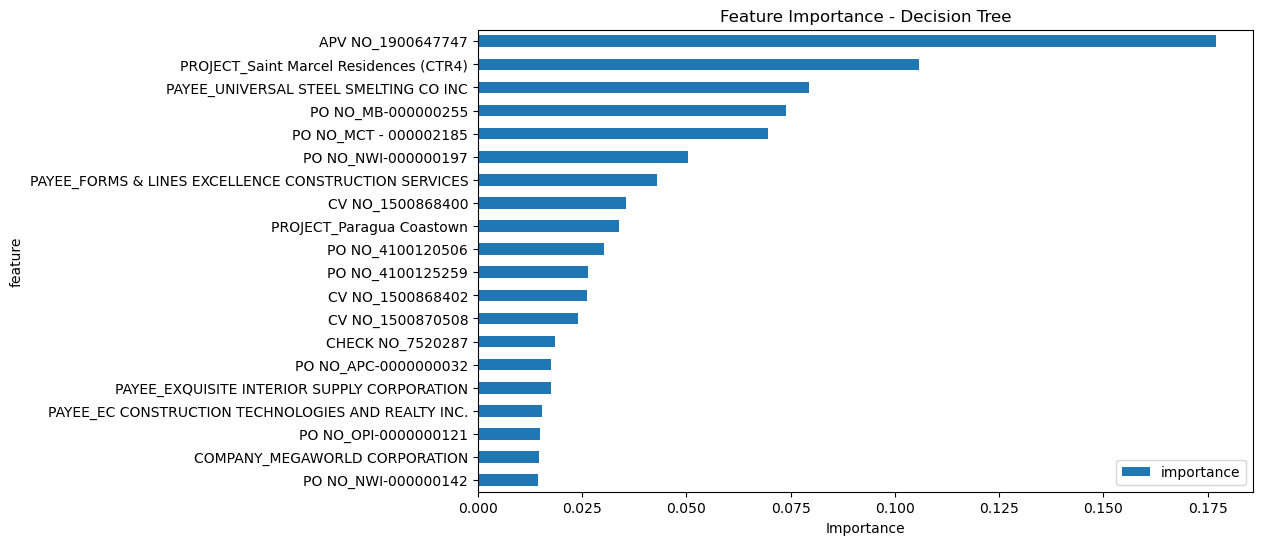

In [9]:
X = df.drop(columns=["AMOUNT"])
y = data_cleaned["AMOUNT"]
    
# Convert categorical variables to numerical using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = DecisionTreeRegressor(max_depth=30, random_state=42)
model.fit(X_train, y_train)

# Feature importance
importance = model.feature_importances_

# Convert to DataFrame
fi_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importance
}).sort_values(by="importance", ascending=False)

# Plot top 20 features
fi_df.head(20).plot(kind='barh', x='feature', y='importance', figsize=(10,6))
plt.gca().invert_yaxis()  # largest on top
plt.xlabel("Importance")
plt.title("Feature Importance - Decision Tree")
plt.show()

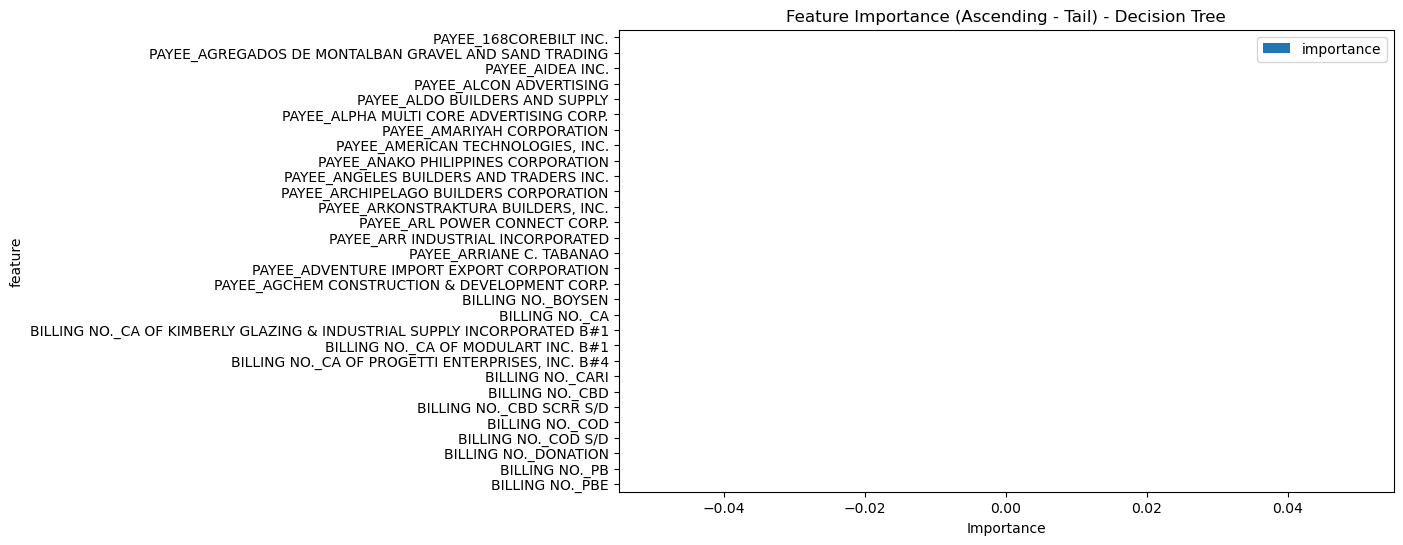

In [13]:
X = df.drop(columns=["AMOUNT"])
y = data_cleaned["AMOUNT"]
    
# Convert categorical variables to numerical using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = DecisionTreeRegressor(max_depth=30, random_state=42)
model.fit(X_train, y_train)

# Feature importance
importance = model.feature_importances_

# Convert to DataFrame
fi_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importance
}).sort_values(by="importance", ascending=True)

# Plot top 20 features
fi_df.head(30).plot(kind='barh', x='feature', y='importance', figsize=(10,6))
plt.gca().invert_yaxis()  # largest on top
plt.xlabel("Importance")
plt.title("Feature Importance (Ascending - Tail) - Decision Tree")
plt.show()

# 8. CONCLUSION

After extensive scikit-learn modeling, the Decision Tree Regressor emerged as the best-performing model, achieving an R² score of 0.577, close to 0.60 which is acceptable - moderate predictive result.

As also observed in other models, is ranging below 0.45. Comparing to Decision Tree Regressor. 

Keep in mind that our data has a valid huge amount that makes MSE get large too.  

To further improve the model, we will focus on enhancing and analyzing the training data. Additionally, we will examine the features with the lowest importance to identify which columns may require attention or improvement.

# 9. RECOMMENDATION

We'll check a pre-modeling analysis before fitting our dataset.

- Non-linear relationships: Linear regression assumes a straight-line relationship. If your data is curved or complex, accuracy will drop.
- Multicollinearity: Strong correlations among predictors inflate variance and make coefficients unstable.
- Outliers: Extreme values can heavily skew the regression line. > Which we've already justified previously.
- Heteroscedasticity: If residuals’ variance changes with the level of the predictor, predictions become unreliable.
- High dimensionality with little data: Too many features relative to observations can lead to overfitting. > The main concern of this


Also, we'll consider in checking the fitness since our target variable is not uniform.

- Residual plots: Random scatter = good fit. Patterns (curves, funnels) = poor fit.
- Q-Q plots: Deviations from the diagonal suggest non-normal residuals.
- Variance Inflation Factor (VIF): High values (>10) indicate multicollinearity.
- Cross-validation: If performance varies wildly across folds, the model is unstable.